## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
#LOAD DATA
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/SLT_PROJECT/5000.csv"
df = pd.read_csv(FILE_PATH)

Mounted at /content/drive


In [3]:
print(df.shape)

(5000, 17)


In [4]:
print(df.head())

         CALL_TIME lang  mainOption subOption IVRPosition existingFault  \
0  5/13/2026 23:59    S        14.0       NaN          S7           NaN   
1  5/13/2026 23:59    S         4.0   extragb       S4112           NaN   
2  5/13/2026 23:59    S         1.0       NaN          S1           NaN   
3  5/13/2026 23:59    S         1.0       NaN       SLty1           NaN   
4  5/13/2026 23:59    S         NaN       NaN           S           NaN   

  suspendedAsset dataLimitExceed extraGBAdded validAccount  outstanding  \
0            NaN             NaN          NaN         True      6467.85   
1            NaN             NaN          NaN         True      2979.45   
2            NaN             NaN          NaN         True       -84.53   
3            NaN             NaN          NaN        False          NaN   
4            NaN             NaN          NaN        False          NaN   

  selectedQueue enteredQueue isAnswered  queue_time  talk_time  total_time  
0            S7      

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CALL_TIME        5000 non-null   object 
 1   lang             4604 non-null   object 
 2   mainOption       3563 non-null   float64
 3   subOption        2400 non-null   object 
 4   IVRPosition      4604 non-null   object 
 5   existingFault    131 non-null    object 
 6   suspendedAsset   645 non-null    object 
 7   dataLimitExceed  51 non-null     object 
 8   extraGBAdded     279 non-null    object 
 9   validAccount     4994 non-null   object 
 10  outstanding      3388 non-null   float64
 11  selectedQueue    3572 non-null   object 
 12  enteredQueue     2713 non-null   object 
 13  isAnswered       787 non-null    object 
 14  queue_time       5000 non-null   int64  
 15  talk_time        5000 non-null   int64  
 16  total_time       5000 non-null   int64  
dtypes: float64(2),

## Select Features and Targets

In [6]:
features = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue',
    'isAnswered'
]

targets = ['queue_time', 'talk_time']

## Clean Data

In [7]:
df = df.copy()

# Convert target columns to numeric
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce')
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce')

# Fill missing feature values
for col in features:
    df[col] = df[col].astype(str).fillna("Unknown")

# Remove rows where queue_time or talk_time is missing
df = df.dropna(subset=['queue_time', 'talk_time'])

print(df.shape)

(5000, 17)


## Encode Categorical Features

In [8]:
encoded_df = df[features].copy()

label_encoders = {}

for col in features:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
    label_encoders[col] = le

print(encoded_df.head())

   lang  mainOption  subOption  IVRPosition  existingFault  suspendedAsset  \
0     1           2          4           80              1               1   
1     1           5          3           64              1               1   
2     1           0          4           47              1               1   
3     1           0          4           81              1               1   
4     1           8          4           46              1               1   

   dataLimitExceed  extraGBAdded  validAccount  outstanding  selectedQueue  \
0                1             1             1         1880             17   
1                1             1             1         1071             12   
2                1             1             1          387              9   
3                1             1             0         2234              9   
4                1             1             0         2234             26   

   enteredQueue  isAnswered  
0             0           0  
1 

## Create Subspaces

In [9]:
# 2D and 3D subspaces are enough for this project
subspaces = []

for r in [2, 3]:
    subspaces.extend(list(itertools.combinations(features, r)))

print("Total subspaces:", len(subspaces))
print(subspaces[:5])

Total subspaces: 364
[('lang', 'mainOption'), ('lang', 'subOption'), ('lang', 'IVRPosition'), ('lang', 'existingFault'), ('lang', 'suspendedAsset')]


## SUBCLU Style Analysis Function

In [10]:
def run_subclu_analysis(encoded_df, original_df, subspaces, target, eps=0.3, min_samples=5, min_cluster_size=30):

    results = []

    for subspace in subspaces:

        subspace = list(subspace)

        X = encoded_df[subspace]

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        temp = original_df.copy()
        temp['Cluster'] = labels

        # Count clusters excluding noise
        number_of_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_count = list(labels).count(-1)
        noise_ratio = noise_count / len(labels)

        # Cluster summary
        cluster_summary = temp.groupby('Cluster')[target].agg(
            ['count', 'mean', 'min', 'max']
        ).reset_index()

        # Remove noise cluster
        cluster_summary = cluster_summary[cluster_summary['Cluster'] != -1]

        # Remove very small clusters
        valid_clusters = cluster_summary[
            cluster_summary['count'] >= min_cluster_size
        ]

        if len(valid_clusters) >= 2:
            separation = valid_clusters['mean'].max() - valid_clusters['mean'].min()
            highest_mean = valid_clusters['mean'].max()
            lowest_mean = valid_clusters['mean'].min()
        else:
            separation = 0
            highest_mean = 0
            lowest_mean = 0

        results.append({
            'Subspace': subspace,
            'Target': target,
            'Separation': separation,
            'Clusters': number_of_clusters,
            'Noise_Count': noise_count,
            'Noise_Ratio': noise_ratio,
            'Highest_Mean': highest_mean,
            'Lowest_Mean': lowest_mean
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by='Separation',
        ascending=False
    )

    return results_df

## Run SUBCLU For Queue Time

In [11]:
queue_results = run_subclu_analysis(
    encoded_df=encoded_df,
    original_df=df,
    subspaces=subspaces,
    target='queue_time',
    eps=0.3,
    min_samples=5,
    min_cluster_size=30
)

queue_results.head(10)

,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
197,"[mainOption, selectedQueue, isAnswered]",queue_time,816.051020,28,29,0.0058,816.051020,0.0
88,"[lang, mainOption, isAnswered]",queue_time,816.051020,31,25,0.0050,816.051020,0.0
162,"[mainOption, IVRPosition, isAnswered]",queue_time,813.879121,40,35,0.0070,813.879121,0.0
278,"[IVRPosition, selectedQueue, isAnswered]",queue_time,813.879121,26,14,0.0028,813.879121,0.0
222,"[subOption, suspendedAsset, isAnswered]",queue_time,810.074713,18,10,0.0020,810.074713,0.0
358,"[validAccount, selectedQueue, isAnswered]",queue_time,809.968085,16,3,0.0006,809.968085,0.0
258,"[IVRPosition, suspendedAsset, isAnswered]",queue_time,805.093567,10,14,0.0028,805.093567,0.0
98,"[lang, subOption, isAnswered]",queue_time,803.573684,25,42,0.0084,803.573684,0.0
242,"[subOption, selectedQueue, isAnswered]",queue_time,803.573684,27,42,0.0084,803.573684,0.0
207,"[subOption, IVRPosition, isAnswered]",queue_time,803.321716,35,61,0.0122,803.321716,0.0


## Run SUBCLU For Talk Time

In [12]:
talk_results = run_subclu_analysis(
    encoded_df=encoded_df,
    original_df=df,
    subspaces=subspaces,
    target='talk_time',
    eps=0.3,
    min_samples=5,
    min_cluster_size=30
)

talk_results.head(10)

,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
358,"[validAccount, selectedQueue, isAnswered]",talk_time,168.500000,16,3,0.0006,168.500000,0.0
137,"[lang, validAccount, isAnswered]",talk_time,168.500000,14,1,0.0002,168.500000,0.0
115,"[lang, existingFault, isAnswered]",talk_time,167.032258,11,1,0.0002,167.032258,0.0
122,"[lang, suspendedAsset, isAnswered]",talk_time,165.742857,9,11,0.0022,165.742857,0.0
128,"[lang, dataLimitExceed, isAnswered]",talk_time,164.171429,9,7,0.0014,164.171429,0.0
215,"[subOption, existingFault, isAnswered]",talk_time,163.750000,20,9,0.0018,163.750000,0.0
228,"[subOption, dataLimitExceed, isAnswered]",talk_time,162.281250,17,9,0.0018,162.281250,0.0
143,"[lang, enteredQueue, isAnswered]",talk_time,162.157895,10,6,0.0012,162.157895,0.0
142,"[lang, selectedQueue, isAnswered]",talk_time,162.157895,10,2,0.0004,162.157895,0.0
133,"[lang, extraGBAdded, isAnswered]",talk_time,162.157895,9,2,0.0004,162.157895,0.0


## Save Final Results

In [13]:
queue_results.to_csv("subclu_queue_time_results.csv", index=False)
talk_results.to_csv("subclu_talk_time_results.csv", index=False)

print("Results saved successfully")

Results saved successfully


## Best Features For Queue Time

In [14]:
print("Best SUBCLU subspaces for Queue Time")
queue_results[['Subspace', 'Separation', 'Clusters', 'Noise_Ratio']].head(10)

Best SUBCLU subspaces for Queue Time


,Subspace,Separation,Clusters,Noise_Ratio
197,"[mainOption, selectedQueue, isAnswered]",816.051020,28,0.0058
88,"[lang, mainOption, isAnswered]",816.051020,31,0.0050
162,"[mainOption, IVRPosition, isAnswered]",813.879121,40,0.0070
278,"[IVRPosition, selectedQueue, isAnswered]",813.879121,26,0.0028
222,"[subOption, suspendedAsset, isAnswered]",810.074713,18,0.0020
358,"[validAccount, selectedQueue, isAnswered]",809.968085,16,0.0006
258,"[IVRPosition, suspendedAsset, isAnswered]",805.093567,10,0.0028
98,"[lang, subOption, isAnswered]",803.573684,25,0.0084
242,"[subOption, selectedQueue, isAnswered]",803.573684,27,0.0084
207,"[subOption, IVRPosition, isAnswered]",803.321716,35,0.0122


## Best Features For Talk Time

In [15]:
print("Best SUBCLU subspaces for Talk Time")
talk_results[['Subspace', 'Separation', 'Clusters', 'Noise_Ratio']].head(10)

Best SUBCLU subspaces for Talk Time


,Subspace,Separation,Clusters,Noise_Ratio
358,"[validAccount, selectedQueue, isAnswered]",168.500000,16,0.0006
137,"[lang, validAccount, isAnswered]",168.500000,14,0.0002
115,"[lang, existingFault, isAnswered]",167.032258,11,0.0002
122,"[lang, suspendedAsset, isAnswered]",165.742857,9,0.0022
128,"[lang, dataLimitExceed, isAnswered]",164.171429,9,0.0014
215,"[subOption, existingFault, isAnswered]",163.750000,20,0.0018
228,"[subOption, dataLimitExceed, isAnswered]",162.281250,17,0.0018
143,"[lang, enteredQueue, isAnswered]",162.157895,10,0.0012
142,"[lang, selectedQueue, isAnswered]",162.157895,10,0.0004
133,"[lang, extraGBAdded, isAnswered]",162.157895,9,0.0004


## Analyze Best Queue Time Subspae

In [16]:
best_queue_subspace = queue_results.iloc[0]['Subspace']

print("Best Queue Time Subspace:", best_queue_subspace)

X = encoded_df[best_queue_subspace]
X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

queue_temp = df.copy()
queue_temp['Cluster'] = labels

queue_cluster_summary = queue_temp.groupby('Cluster')['queue_time'].agg(
    ['count', 'mean', 'min', 'max']
).sort_values('mean', ascending=False)

queue_cluster_summary

Best Queue Time Subspace: ['mainOption', 'selectedQueue', 'isAnswered']


,count,mean,min,max
Cluster,,,,
9,19,835.368421,209,1150
0,98,816.051020,162,1200
5,450,792.120000,99,1655
11,85,739.964706,168,1107
2,57,698.350877,67,1184
25,8,559.875000,287,809
14,21,484.142857,0,894
17,8,483.250000,19,1114
-1,29,348.068966,0,1002


## Analyze Best Talk Time Subspace

In [17]:
best_talk_subspace = talk_results.iloc[0]['Subspace']

print("Best Talk Time Subspace:", best_talk_subspace)

X = encoded_df[best_talk_subspace]
X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

talk_temp = df.copy()
talk_temp['Cluster'] = labels

talk_cluster_summary = talk_temp.groupby('Cluster')['talk_time'].agg(
    ['count', 'mean', 'min', 'max']
).sort_values('mean', ascending=False)

talk_cluster_summary

Best Talk Time Subspace: ['validAccount', 'selectedQueue', 'isAnswered']


,count,mean,min,max
Cluster,,,,
13,9,203.333333,87,662
12,5,170.400000,20,369
10,30,168.500000,29,595
6,45,149.000000,0,409
5,27,138.962963,30,743
0,94,136.925532,0,792
-1,3,134.333333,42,249
9,7,116.142857,14,278
2,567,112.619048,0,868


## Visualize Best Queue Time Subspace

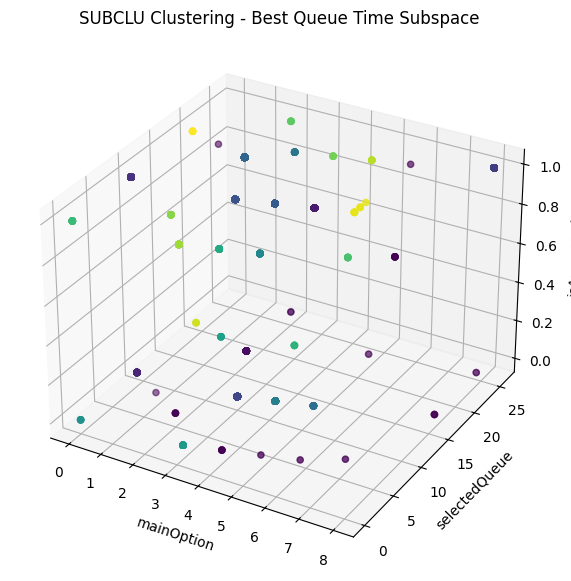

In [20]:
from mpl_toolkits.mplot3d import Axes3D

# Queue Time 3D plot
if len(best_queue_subspace) == 3:

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        encoded_df[best_queue_subspace[0]],
        encoded_df[best_queue_subspace[1]],
        encoded_df[best_queue_subspace[2]],
        c=queue_temp['Cluster']
    )

    ax.set_xlabel(best_queue_subspace[0])
    ax.set_ylabel(best_queue_subspace[1])
    ax.set_zlabel(best_queue_subspace[2])
    ax.set_title("SUBCLU Clustering - Best Queue Time Subspace")

    plt.show()

## Visualize Best Talk Time Subspace

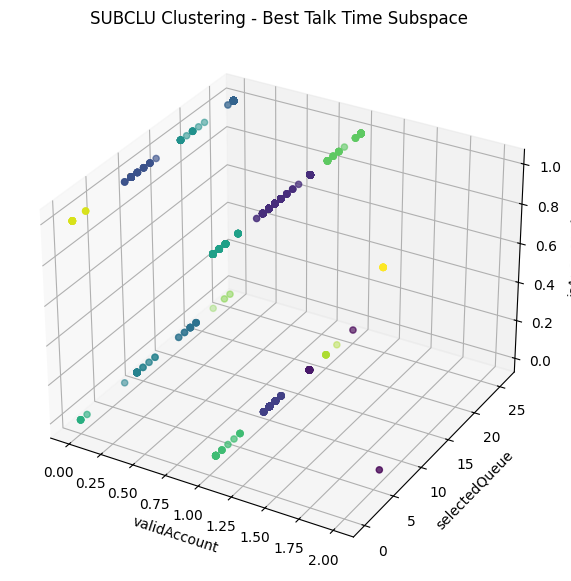

In [21]:
# Talk Time 3D plot
if len(best_talk_subspace) == 3:

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        encoded_df[best_talk_subspace[0]],
        encoded_df[best_talk_subspace[1]],
        encoded_df[best_talk_subspace[2]],
        c=talk_temp['Cluster']
    )

    ax.set_xlabel(best_talk_subspace[0])
    ax.set_ylabel(best_talk_subspace[1])
    ax.set_zlabel(best_talk_subspace[2])
    ax.set_title("SUBCLU Clustering - Best Talk Time Subspace")

    plt.show()

In [22]:
print(best_queue_subspace)
print(len(best_queue_subspace))

print(best_talk_subspace)
print(len(best_talk_subspace))

['mainOption', 'selectedQueue', 'isAnswered']
3
['validAccount', 'selectedQueue', 'isAnswered']
3


## WITHOUT isAnswered

In [23]:
# CREATE SUBSPACES WITHOUT isAnswered


features_no_answered = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue'
]

subspaces_no_answered = []

for r in [2, 3]:
    subspaces_no_answered.extend(list(itertools.combinations(features_no_answered, r)))

print("Total subspaces without isAnswered:", len(subspaces_no_answered))

Total subspaces without isAnswered: 286


In [24]:
# RUN SUBCLU WITHOUT isAnswered - QUEUE TIME


queue_results_no_answered = run_subclu_analysis(
    encoded_df=encoded_df,
    original_df=df,
    subspaces=subspaces_no_answered,
    target='queue_time',
    eps=0.3,
    min_samples=5,
    min_cluster_size=30
)

queue_results_no_answered.head(10)

,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
173,"[subOption, IVRPosition, enteredQueue]",queue_time,282.796875,38,45,0.0090,282.796875,0.000000
172,"[subOption, IVRPosition, selectedQueue]",queue_time,278.446154,37,26,0.0052,278.446154,0.000000
169,"[subOption, IVRPosition, extraGBAdded]",queue_time,278.446154,28,32,0.0064,278.446154,0.000000
76,"[lang, subOption, IVRPosition]",queue_time,278.446154,30,24,0.0048,278.446154,0.000000
121,"[mainOption, subOption, IVRPosition]",queue_time,278.446154,38,28,0.0056,278.446154,0.000000
110,"[lang, dataLimitExceed, enteredQueue]",queue_time,273.656250,9,8,0.0016,273.656250,0.000000
275,"[dataLimitExceed, selectedQueue, enteredQueue]",queue_time,273.656250,7,7,0.0014,273.656250,0.000000
171,"[subOption, IVRPosition, outstanding]",queue_time,272.679487,30,117,0.0234,278.446154,5.766667
166,"[subOption, IVRPosition, existingFault]",queue_time,272.679487,28,35,0.0070,278.446154,5.766667
21,"[subOption, IVRPosition]",queue_time,272.679487,25,24,0.0048,278.446154,5.766667


In [25]:
# RUN SUBCLU WITHOUT isAnswered - TALK TIME

talk_results_no_answered = run_subclu_analysis(
    encoded_df=encoded_df,
    original_df=df,
    subspaces=subspaces_no_answered,
    target='talk_time',
    eps=0.3,
    min_samples=5,
    min_cluster_size=30
)

talk_results_no_answered.head(10)

,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
116,"[lang, validAccount, selectedQueue]",talk_time,80.942857,12,3,0.0006,80.942857,0.000000
197,"[subOption, validAccount, selectedQueue]",talk_time,71.619048,26,19,0.0038,72.153846,0.534799
165,"[mainOption, selectedQueue, enteredQueue]",talk_time,70.416667,25,28,0.0056,70.416667,0.000000
75,"[lang, mainOption, enteredQueue]",talk_time,70.416667,28,25,0.0050,70.416667,0.000000
119,"[lang, outstanding, enteredQueue]",talk_time,69.979167,9,10,0.0020,69.979167,0.000000
137,"[mainOption, IVRPosition, enteredQueue]",talk_time,69.872340,34,33,0.0066,69.872340,0.000000
223,"[IVRPosition, extraGBAdded, enteredQueue]",talk_time,68.629032,7,5,0.0010,68.629032,0.000000
92,"[lang, IVRPosition, enteredQueue]",talk_time,68.629032,11,3,0.0006,68.629032,0.000000
37,"[IVRPosition, enteredQueue]",talk_time,68.192215,3,0,0.0000,68.629032,0.436817
284,"[validAccount, selectedQueue, enteredQueue]",talk_time,67.265306,13,13,0.0026,67.265306,0.000000


In [27]:
print("WITH isAnswered - Queue Time")
display(queue_results.head(5))

print("WITHOUT isAnswered - Queue Time")
display(queue_results_no_answered.head(5))

WITH isAnswered - Queue Time


,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
197,"[mainOption, selectedQueue, isAnswered]",queue_time,816.051020,28,29,0.0058,816.051020,0.0
88,"[lang, mainOption, isAnswered]",queue_time,816.051020,31,25,0.0050,816.051020,0.0
162,"[mainOption, IVRPosition, isAnswered]",queue_time,813.879121,40,35,0.0070,813.879121,0.0
278,"[IVRPosition, selectedQueue, isAnswered]",queue_time,813.879121,26,14,0.0028,813.879121,0.0
222,"[subOption, suspendedAsset, isAnswered]",queue_time,810.074713,18,10,0.0020,810.074713,0.0


WITHOUT isAnswered - Queue Time


,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
173,"[subOption, IVRPosition, enteredQueue]",queue_time,282.796875,38,45,0.0090,282.796875,0.0
172,"[subOption, IVRPosition, selectedQueue]",queue_time,278.446154,37,26,0.0052,278.446154,0.0
169,"[subOption, IVRPosition, extraGBAdded]",queue_time,278.446154,28,32,0.0064,278.446154,0.0
76,"[lang, subOption, IVRPosition]",queue_time,278.446154,30,24,0.0048,278.446154,0.0
121,"[mainOption, subOption, IVRPosition]",queue_time,278.446154,38,28,0.0056,278.446154,0.0


In [28]:
print("WITH isAnswered - Talk Time")
display(talk_results.head(5))

print("WITHOUT isAnswered - Talk Time")
display(talk_results_no_answered.head(5))

WITH isAnswered - Talk Time


,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
358,"[validAccount, selectedQueue, isAnswered]",talk_time,168.500000,16,3,0.0006,168.500000,0.0
137,"[lang, validAccount, isAnswered]",talk_time,168.500000,14,1,0.0002,168.500000,0.0
115,"[lang, existingFault, isAnswered]",talk_time,167.032258,11,1,0.0002,167.032258,0.0
122,"[lang, suspendedAsset, isAnswered]",talk_time,165.742857,9,11,0.0022,165.742857,0.0
128,"[lang, dataLimitExceed, isAnswered]",talk_time,164.171429,9,7,0.0014,164.171429,0.0


WITHOUT isAnswered - Talk Time


,Subspace,Target,Separation,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
116,"[lang, validAccount, selectedQueue]",talk_time,80.942857,12,3,0.0006,80.942857,0.000000
197,"[subOption, validAccount, selectedQueue]",talk_time,71.619048,26,19,0.0038,72.153846,0.534799
165,"[mainOption, selectedQueue, enteredQueue]",talk_time,70.416667,25,28,0.0056,70.416667,0.000000
75,"[lang, mainOption, enteredQueue]",talk_time,70.416667,28,25,0.0050,70.416667,0.000000
119,"[lang, outstanding, enteredQueue]",talk_time,69.979167,9,10,0.0020,69.979167,0.000000


- Since isAnswered directly affects Queue Time and Talk Time values, an additional analysis was conducted excluding this attribute to identify the underlying operational factors influencing call behavior.

## Final Conclusion


- SUBCLU analysis was performed on the SLT Call Center dataset to identify the feature subspaces that best define Queue Time and Talk Time.

- For Queue Time, the most informative subspace was:
[subOption, IVRPosition, enteredQueue]

- For Talk Time, the most informative subspace was:
[lang, validAccount, selectedQueue]

- These feature combinations produced the highest separation between cluster averages and therefore provide the strongest explanation of Queue Time and Talk Time behaviour within the dataset.